# 📊 IPL Player Performance Analysis

This project analyzes IPL player performance using batting metrics such as runs, boundaries, and consistency to identify performance patterns and player styles.

## 🎯 Objective

- To analyze player performance based on batting statistics  
- To identify top performers  
- To study relationships between performance metrics  
- To apply regression analysis for deeper insights  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 Dataset Overview

The dataset contains IPL player statistics including runs, fours, sixes, fifties, and centuries.

Each row represents a player, and multiple performance metrics are used to evaluate their batting performance.

In [ ]:
df = pd.read_excel("IPL_Cleaned_Data.xlsx", sheet_name="Master_Data")
df.head()

,Year,Rank by runs,Player,Team,Total Runs Scored,Total Matches Played,Total Innings Played,Not Outs,Highest Score,Highest Score (NOT OUT),...,Balls Faced,Strike Rate,Total Centuries,Total Fifties,Total Fours,Total Sixes,Rank by centuries,Rank by fifties,Rank by fours,Rank by sixes
0,2025,1,Sai Sudharsan,GT,759,15,15,1,108,1,...,486,156.17,1,6,88,21,10,7,1,101
1,2025,2,Surya Kumar Yadav,MI,717,16,16,5,73,1,...,427,167.91,0,5,69,38,61,23,8,6
2,2025,3,Virat Kohli,RCB,657,15,15,3,73,1,...,454,144.71,0,8,66,19,61,2,12,127
3,2025,4,Shubman Gill,GT,650,15,15,2,93,1,...,417,155.87,0,6,62,24,61,7,22,65
4,2025,5,Mitchell Marsh,LSG,627,13,13,0,117,0,...,383,163.70,1,6,56,37,10,7,35,10


## 🧹 Data Understanding

The dataset is clean with no missing values. Most columns are numerical and represent different performance indicators.

Descriptive statistics show variation in player performance, indicating both high-performing and average players.

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     500 non-null    int64  
 1   Rank by runs             500 non-null    int64  
 2   Player                   500 non-null    object 
 3   Team                     500 non-null    object 
 4   Total Runs Scored        500 non-null    int64  
 5   Total Matches Played     500 non-null    int64  
 6   Total Innings Played     500 non-null    int64  
 7   Not Outs                 500 non-null    int64  
 8   Highest Score            500 non-null    int64  
 9   Highest Score (NOT OUT)  500 non-null    int64  
 10  Average                  500 non-null    float64
 11  Balls Faced              500 non-null    int64  
 12  Strike Rate              500 non-null    float64
 13  Total Centuries          500 non-null    int64  
 14  Total Fifties            5

,Year,Rank by runs,Total Runs Scored,Total Matches Played,Total Innings Played,Not Outs,Highest Score,Highest Score (NOT OUT),Average,Balls Faced,Strike Rate,Total Centuries,Total Fifties,Total Fours,Total Sixes,Rank by centuries,Rank by fifties,Rank by fours,Rank by sixes
count,500.000000,500.000000,500.00000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2020.500000,25.500000,335.08400,13.006000,12.28000,2.064000,72.040000,0.398000,33.362720,235.554000,142.624300,0.148000,2.098000,30.322000,14.876000,54.758000,204.728000,245.626000,241.024000
std,2.875158,14.445322,144.41951,2.807441,2.78516,1.884411,21.829509,0.489976,11.916993,97.875709,19.885417,0.458821,1.681085,15.864984,8.440563,16.941945,131.313031,143.346554,142.005403
min,2016.000000,1.000000,110.00000,4.000000,4.00000,0.000000,25.000000,0.000000,10.280000,64.000000,93.060000,0.000000,0.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2018.000000,13.000000,230.00000,11.750000,11.00000,1.000000,55.000000,0.000000,25.102500,163.000000,128.057500,0.000000,1.000000,19.000000,9.000000,61.000000,93.000000,122.000000,120.000000
50%,2020.500000,25.500000,313.50000,14.000000,13.00000,2.000000,70.000000,0.000000,31.250000,218.500000,140.470000,0.000000,2.000000,27.000000,13.000000,61.000000,176.000000,248.000000,244.000000
75%,2023.000000,38.000000,418.00000,15.000000,14.00000,3.000000,87.000000,1.000000,39.500000,290.250000,153.385000,0.000000,3.000000,40.000000,20.000000,61.000000,287.000000,365.000000,356.000000
max,2025.000000,50.000000,973.00000,17.000000,17.00000,10.000000,141.000000,1.000000,83.200000,640.000000,234.040000,4.000000,9.000000,88.000000,52.000000,61.000000,418.000000,500.000000,498.000000


## 🧠 Feature Engineering

To enhance analysis, new features were created:

- Consistency Score = Fifties + Centuries  
- Boundary Score = Fours + (2 × Sixes)

These help in identifying reliable and aggressive players.

In [ ]:
df['Consistency'] = df['Total Fifties'] + df['Total Centuries']

In [ ]:
df['Boundary Score'] = df['Total Fours'] + (df['Total Sixes'] * 2)

## 📊 Top Run Scorers

This analysis identifies the top 10 players based on total runs scored to understand leading performers.

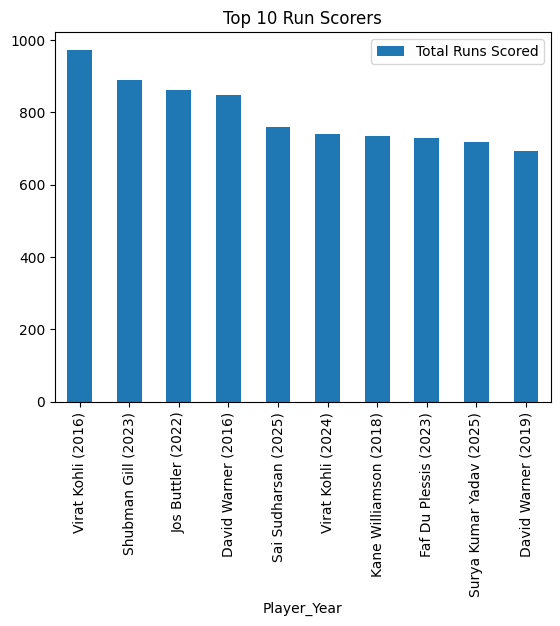

In [ ]:
df['Player_Year'] = df['Player'] + " (" + df['Year'].astype(str) + ")"
top_runs = df.sort_values(by='Total Runs Scored', ascending=False).head(10)
top_runs.plot(x='Player_Year', y='Total Runs Scored', kind='bar')
plt.title("Top 10 Run Scorers")
plt.xticks(rotation=90)
plt.show()

The chart shows that a few players dominate total run scoring, indicating strong and consistent batting performance.

## 💥 Top Players by Sixes

This analysis highlights players with the highest number of sixes to identify aggressive batsmen.

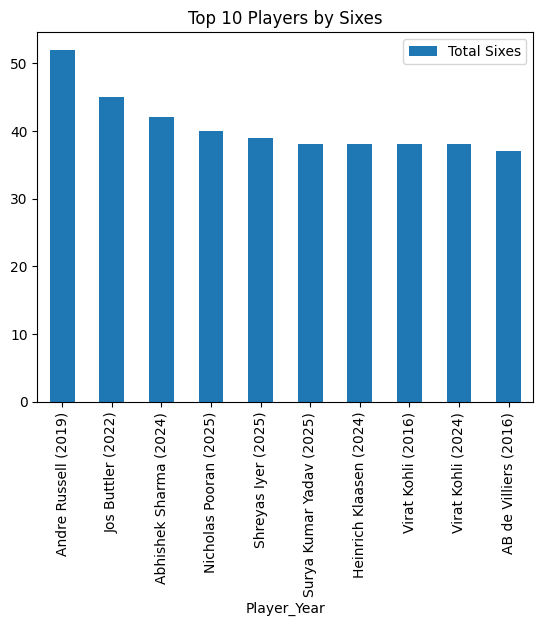

In [ ]:
df['Player_Year'] = df['Player'] + " (" + df['Year'].astype(str) + ")"
top_six = df.sort_values(by='Total Sixes', ascending=False).head(10)
top_six.plot(x='Player_Year', y='Total Sixes', kind='bar')
plt.title("Top 10 Players by Sixes")
plt.xticks(rotation=90)
plt.show()

Players with higher six counts demonstrate an aggressive playing style and contribute significantly to scoring.

## 🎯 Most Consistent Players

Consistency is measured using fifties and centuries to identify reliable performers.

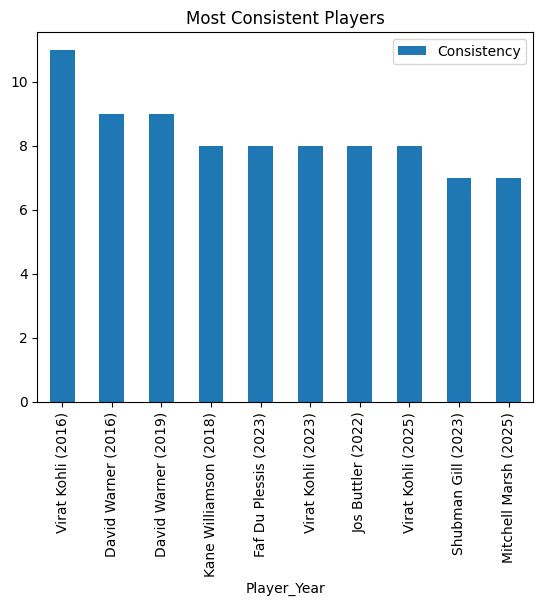

In [ ]:
df['Player_Year'] = df['Player'] + " (" + df['Year'].astype(str) + ")"
top_consistent = df.sort_values(by='Consistency', ascending=False).head(10)
top_consistent.plot(x='Player_Year', y='Consistency', kind='bar')
plt.title("Most Consistent Players")
plt.xticks(rotation=90)
plt.show()

Players with higher consistency scores perform steadily across matches and are key contributors to team success.

## 🔗 Fours vs Sixes Relationship

This analysis examines the relationship between fours and sixes to understand player batting style.

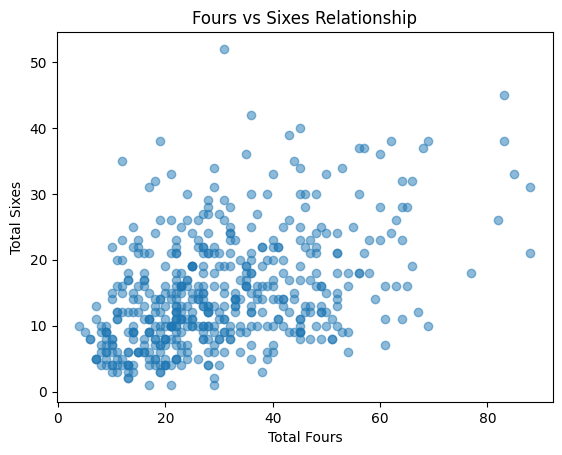

In [ ]:
plt.scatter(df['Total Fours'], df['Total Sixes'], alpha=0.5)
plt.xlabel("Total Fours")
plt.ylabel("Total Sixes")
plt.title("Fours vs Sixes Relationship")
plt.show()

A positive relationship is observed, indicating that players who hit more fours also tend to hit more sixes.

## 📈 Runs vs Consistency

This analysis explores how consistency impacts total runs scored.

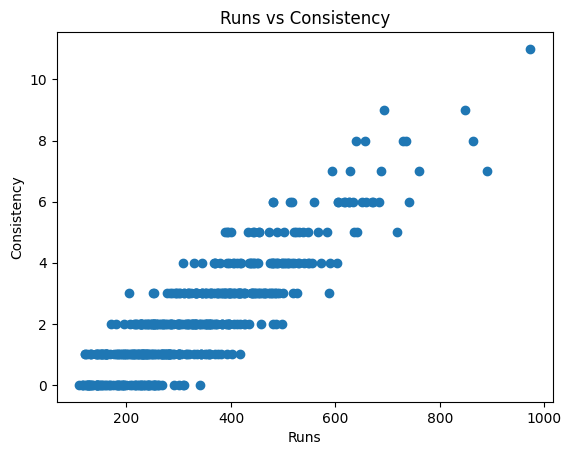

In [ ]:
plt.scatter(df['Total Runs Scored'], df['Consistency'])
plt.xlabel("Runs")
plt.ylabel("Consistency")
plt.title("Runs vs Consistency")
plt.show()

A strong positive relationship is observed, showing that consistent players tend to score more runs.

## 📊 Correlation Analysis

Correlation is used to identify relationships between different performance metrics.

In [ ]:
df.corr(numeric_only=True)

,Year,Rank by runs,Total Runs Scored,Total Matches Played,Total Innings Played,Not Outs,Highest Score,Highest Score (NOT OUT),Average,Balls Faced,...,Total Centuries,Total Fifties,Total Fours,Total Sixes,Rank by centuries,Rank by fifties,Rank by fours,Rank by sixes,Consistency,Boundary Score
Year,1.000000e+00,1.916996e-14,0.178842,0.094467,0.110364,-0.022933,0.140458,0.016359,0.103697,0.075761,...,0.088109,0.097228,0.138809,0.309917,-0.127846,-0.117896,-0.160564,-0.350371,0.111889,0.266840
Rank by runs,1.916996e-14,1.000000e+00,-0.910515,-0.488495,-0.642757,-0.026062,-0.619967,-0.196073,-0.599778,-0.896523,...,-0.329878,-0.759761,-0.827422,-0.600134,0.338250,0.761959,0.846463,0.603417,-0.784019,-0.834841
Total Runs Scored,1.788424e-01,-9.105155e-01,1.000000,0.497752,0.643157,0.028227,0.657448,0.198279,0.657787,0.951548,...,0.468826,0.821003,0.903006,0.697497,-0.422754,-0.759518,-0.854725,-0.668721,0.875509,0.936881
Total Matches Played,9.446734e-02,-4.884950e-01,0.497752,1.000000,0.918087,0.371533,0.077822,0.148316,0.094311,0.502397,...,0.075542,0.281397,0.397339,0.368335,-0.038437,-0.261234,-0.390974,-0.377607,0.278639,0.449463
Total Innings Played,1.103637e-01,-6.427565e-01,0.643157,0.918087,1.000000,0.244770,0.216009,0.119360,0.123975,0.658004,...,0.144715,0.407163,0.563648,0.437602,-0.113316,-0.395028,-0.569292,-0.447067,0.412088,0.586144
Not Outs,-2.293262e-02,-2.606152e-02,0.028227,0.371533,0.244770,1.000000,-0.167892,0.419469,0.440643,-0.004778,...,-0.050380,-0.056388,-0.154798,0.108477,0.090688,0.095741,0.186918,-0.094231,-0.064710,-0.022422
Highest Score,1.404584e-01,-6.199674e-01,0.657448,0.077822,0.216009,-0.167892,1.000000,0.203482,0.511783,0.594161,...,0.568846,0.563405,0.634221,0.490704,-0.639923,-0.613391,-0.636934,-0.502941,0.663036,0.658510
Highest Score (NOT OUT),1.635916e-02,-1.960729e-01,0.198279,0.148316,0.119360,0.419469,0.203482,1.000000,0.374547,0.183438,...,0.111855,0.154488,0.085054,0.168957,-0.152052,-0.125301,-0.060876,-0.162897,0.170696,0.150815
Average,1.036967e-01,-5.997776e-01,0.657787,0.094311,0.123975,0.440643,0.511783,0.374547,1.000000,0.574121,...,0.352391,0.587578,0.505180,0.523298,-0.320143,-0.540788,-0.465918,-0.495001,0.630833,0.604775
Balls Faced,7.576057e-02,-8.965234e-01,0.951548,0.502397,0.658004,-0.004778,0.594161,0.183438,0.574121,1.000000,...,0.411758,0.785927,0.881838,0.505914,-0.355834,-0.735642,-0.841188,-0.493744,0.828778,0.808737


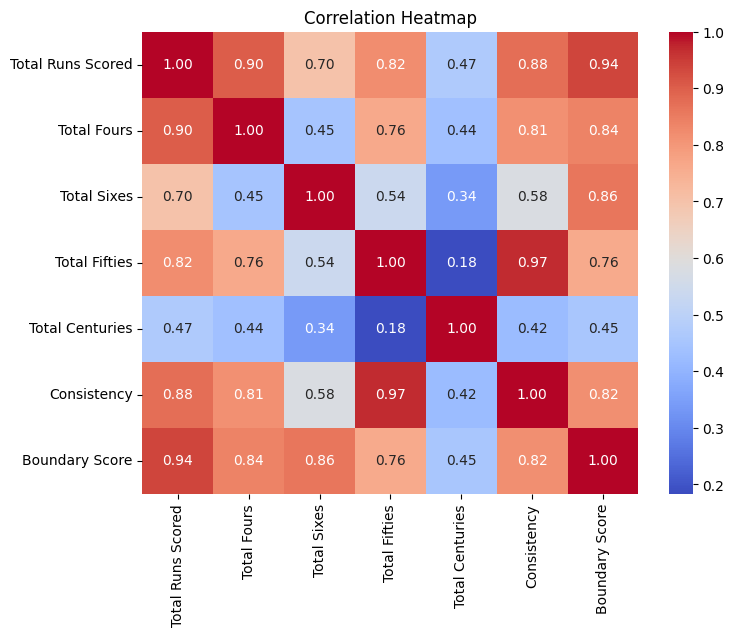

In [ ]:
cols = ['Total Runs Scored', 'Total Fours', 'Total Sixes',
        'Total Fifties', 'Total Centuries', 'Consistency', 'Boundary Score']
plt.figure(figsize=(8,6))
sns.heatmap(df[cols].corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Strong positive relationships exist between runs, boundaries, and consistency, indicating their importance in performance.

## 🧩 Player Classification

Players are categorized based on their playing style.

In [ ]:
def player_type(row):
    if row['Total Sixes'] > row['Total Fours']:
        return "Power Hitter"
    elif row['Total Fours'] > row['Total Sixes']:
        return "Classical Batsman"
    else:
        return "Balanced Player"

df['Player Type'] = df.apply(player_type, axis=1)

This classification helps in understanding different batting styles among players.

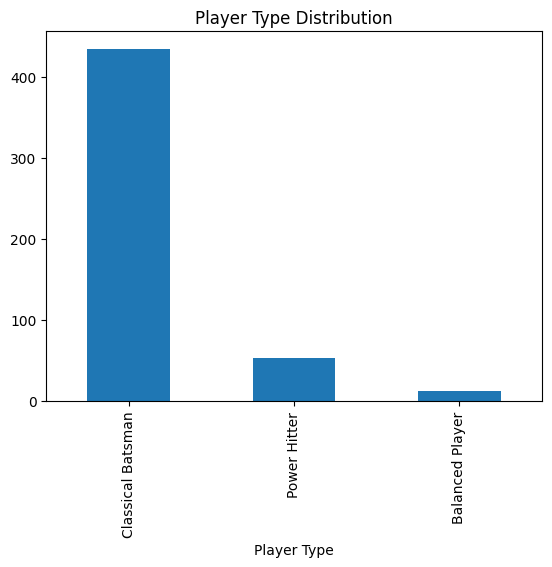

In [ ]:
df['Player Type'].value_counts().plot(kind='bar')
plt.title("Player Type Distribution")
plt.show()

## 🤖 Regression Analysis

Linear regression is used to analyze the impact of batting metrics on total runs scored.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
X = df[['Total Fours', 'Total Sixes', 'Total Fifties', 'Total Centuries']]
y = df['Total Runs Scored']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 56.54961345380991
Coefficients: [ 5.25116903  5.30512895 18.250305   22.52309342]


In [ ]:
comparison = pd.DataFrame({
    'Actual Runs': y_test.values,
    'Predicted Runs': y_pred
})

print("\nActual vs Predicted:")
print(comparison)


Actual vs Predicted:
    Actual Runs  Predicted Runs
0           480      530.000904
1           359      354.299433
2           286      287.990997
3           481      383.105598
4           625      738.853445
..          ...             ...
95          123      119.779481
96          267      232.766669
97          351      345.861776
98          229      243.322967
99          418      461.561601

[100 rows x 2 columns]


In [ ]:
print("\nModel Evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Model Evaluation:
MAE: 33.42610833235116
MSE: 1739.9267235929804
R2 Score: 0.9255999555362769


The model shows a strong relationship between batting metrics and total runs.

The R² score indicates that most of the variation in runs is explained by the selected variables, highlighting the importance of boundaries and consistency.

Higher coefficients for fifties and centuries indicate that consistency has a slightly stronger impact on total runs compared to boundaries.

### 📊 Actual vs Predicted Runs

The scatter plot compares actual runs with predicted runs from the regression model.

The points are closely aligned along a straight line, indicating that the model's predictions are very close to actual values.

This confirms that the model has high accuracy and effectively captures the relationship between batting metrics and total runs.

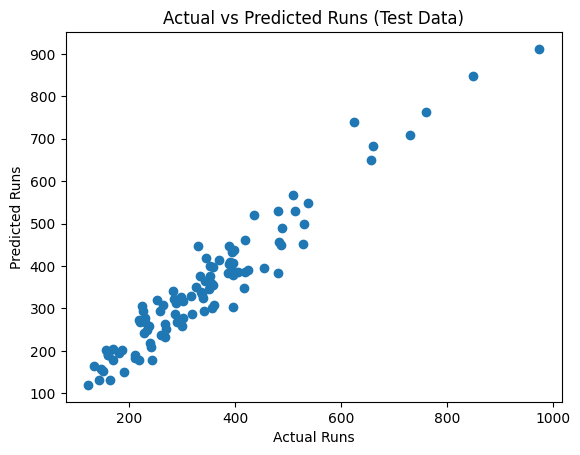

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Runs")
plt.ylabel("Predicted Runs")
plt.title("Actual vs Predicted Runs (Test Data)")
plt.show()

## 🏁 Conclusion

The analysis shows that both consistency and boundary-hitting ability are crucial for player performance.

Players who maintain a balance between aggressive and stable batting tend to perform better overall.